# 05 - Rotulo humano contra rotulo automatico

O notebook 04 mostrou que o CRF treinado com rotulo automatico empata com as
regras que o rotularam: micro F1 0,938 contra 0,946, com empate exato em oito
das doze entidades. O diagnostico foi que o modelo herda o teto do rotulador.

Este notebook testa esse diagnostico com um experimento direto:

> 39 titulos revisados por uma pessoa valem mais que 983 titulos rotulados
> automaticamente?

Se valerem, a hipotese do teto se confirma, e fica demonstrado com numero que o
gargalo do problema e a qualidade da anotacao, nao o volume.

O conjunto revisado tem 49 titulos, pouco para separar treino e teste. Por isso
a avaliacao usa **validacao cruzada em 5 particoes**: o modelo e treinado em
quatro quintos e prediz o quinto restante, cinco vezes, de modo que todo titulo
e predito exatamente uma vez por um modelo que nao o viu no treino. As predicoes
sao reunidas e avaliadas contra os 49, o que torna a comparacao com os outros
dois sistemas justa, ja que todos sao medidos no mesmo conjunto.

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent))

import random

import pandas as pd
import sklearn_crfsuite

from src.dados import (
    carregar_produtos, titulos_unicos, marcas_do_catalogo,
    carregar_jsonl, DIR_ANOT,
)
from src.preanotacao import anotar_titulo, _regex_marcas
from src.avaliacao import para_bio, de_bio, avaliar, erros

BASE = "cellphone"
SEMENTE = 42

teste = carregar_jsonl(DIR_ANOT / f"{BASE}.ibyte.teste.jsonl")
treino_auto = carregar_jsonl(DIR_ANOT / f"{BASE}.ibyte.treino_auto.jsonl")

print(f"revisado manualmente: {len(teste)} titulos, {sum(len(r['entities']) for r in teste)} entidades")
print(f"rotulo automatico:    {len(treino_auto)} titulos, {sum(len(r['entities']) for r in treino_auto)} entidades")

revisado manualmente: 49 titulos, 311 entidades
rotulo automatico:    983 titulos, 5499 entidades


## 1. Caracteristicas e utilitarios

As mesmas do notebook 04, repetidas aqui para o notebook ser independente.

In [2]:
def caracteristicas(tokens, i):
    token = tokens[i]
    f = {
        "vies": 1.0,
        "minusculo": token.lower(),
        "sufixo3": token[-3:],
        "sufixo2": token[-2:],
        "prefixo2": token[:2],
        "maiuscula_inicial": token[:1].isupper(),
        "tudo_maiusculo": token.isupper(),
        "tem_digito": any(c.isdigit() for c in token),
        "so_digito": token.isdigit(),
        "alfanumerico": any(c.isdigit() for c in token) and any(c.isalpha() for c in token),
        "tamanho": len(token),
        "posicao": i,
        "primeiro": i == 0,
        "ultimo": i == len(tokens) - 1,
    }
    if i > 0:
        f.update({"-1:minusculo": tokens[i - 1].lower(),
                  "-1:tem_digito": any(c.isdigit() for c in tokens[i - 1]),
                  "-1:maiuscula": tokens[i - 1][:1].isupper()})
    if i > 1:
        f["-2:minusculo"] = tokens[i - 2].lower()
    if i < len(tokens) - 1:
        f.update({"+1:minusculo": tokens[i + 1].lower(),
                  "+1:tem_digito": any(c.isdigit() for c in tokens[i + 1])})
    if i < len(tokens) - 2:
        f["+2:minusculo"] = tokens[i + 2].lower()
    return f


def vetorizar(registros):
    X, y = [], []
    for registro in registros:
        tokens, rotulos = para_bio(registro)
        X.append([caracteristicas(tokens, i) for i in range(len(tokens))])
        y.append(rotulos)
    return X, y


def novo_crf():
    return sklearn_crfsuite.CRF(algorithm="lbfgs", c1=0.1, c2=0.1,
                                max_iterations=200, all_possible_transitions=True)


def micro_f1(referencia, predicao):
    return [l for l in avaliar(referencia, predicao) if l["tag"] == "micro"][0]["f1"]

## 2. Sistema A: regras

Baseline, reproduzido aqui para a tabela final.

In [4]:
produtos = titulos_unicos(carregar_produtos(BASE))
marcas = _regex_marcas(marcas_do_catalogo(produtos))

pred_regras = [{"text": r["text"], "entities": anotar_titulo(r["text"], marcas)} for r in teste]
res_regras = pd.DataFrame(avaliar(teste, pred_regras))
print(f"micro F1: {micro_f1(teste, pred_regras):.3f}")

micro F1: 0.946


## 3. Sistema B: CRF treinado com rotulo automatico

983 titulos de treino, nenhum revisado.

In [6]:
X_teste, _ = vetorizar(teste)

X_auto, y_auto = vetorizar(treino_auto)
crf_auto = novo_crf()
crf_auto.fit(X_auto, y_auto)

pred_auto = [{"text": r["text"], "entities": de_bio(r["text"], rot)}
             for r, rot in zip(teste, crf_auto.predict(X_teste))]
res_auto = pd.DataFrame(avaliar(teste, pred_auto))
print(f"micro F1: {micro_f1(teste, pred_auto):.3f}")

micro F1: 0.938


## 4. Sistema C: CRF treinado com rotulo humano

Validacao cruzada em 5 particoes sobre os 49 titulos revisados. Cada particao e
predita por um modelo treinado nas outras quatro, com cerca de 39 titulos de
treino. Nenhum titulo e predito por um modelo que o viu.

Compare a escala: 39 titulos revisados contra 983 rotulados automaticamente.

In [8]:
PARTICOES = 5

indices = list(range(len(teste)))
random.Random(SEMENTE).shuffle(indices)
particoes = [indices[i::PARTICOES] for i in range(PARTICOES)]

pred_humano = [None] * len(teste)
tamanhos_treino = []

for numero, particao in enumerate(particoes, 1):
    fora = [i for i in indices if i not in set(particao)]
    treino_parcial = [teste[i] for i in fora]
    tamanhos_treino.append(len(treino_parcial))

    Xp, yp = vetorizar(treino_parcial)
    modelo = novo_crf()
    modelo.fit(Xp, yp)

    alvo = [teste[i] for i in particao]
    Xa, _ = vetorizar(alvo)
    for i, rotulos in zip(particao, modelo.predict(Xa)):
        pred_humano[i] = {"text": teste[i]["text"], "entities": de_bio(teste[i]["text"], rotulos)}

    print(f"particao {numero}: treino {len(treino_parcial)} titulos, prediz {len(particao)}")

res_humano = pd.DataFrame(avaliar(teste, pred_humano))
print(f"\nmicro F1: {micro_f1(teste, pred_humano):.3f}")

particao 1: treino 39 titulos, prediz 10
particao 2: treino 39 titulos, prediz 10
particao 3: treino 39 titulos, prediz 10
particao 4: treino 39 titulos, prediz 10
particao 5: treino 40 titulos, prediz 9

micro F1: 0.818


## 5. Comparacao dos tres sistemas

In [10]:
comparacao = (
    res_regras[["tag", "suporte", "f1"]].rename(columns={"f1": "regras"})
    .merge(res_auto[["tag", "f1"]].rename(columns={"f1": "crf_automatico"}), on="tag", how="outer")
    .merge(res_humano[["tag", "f1"]].rename(columns={"f1": "crf_humano"}), on="tag", how="outer")
)
comparacao["ganho_humano"] = comparacao["crf_humano"] - comparacao["crf_automatico"]
comparacao.sort_values("suporte", ascending=False).round(3)

,tag,suporte,regras,crf_automatico,crf_humano,ganho_humano
12,macro,311,0.870,0.860,0.747,-0.113
13,micro,311,0.946,0.938,0.818,-0.119
4,MARCA,51,0.970,0.960,0.875,-0.085
11,TIPO,45,1.000,1.000,0.857,-0.143
3,COR,37,0.866,0.866,0.677,-0.188
6,MODELO,35,0.814,0.814,0.667,-0.147
5,MEMORIA,31,1.000,0.967,0.951,-0.016
10,TELA,24,0.957,0.957,0.826,-0.130
1,CODIGO,21,0.950,0.950,0.889,-0.061
0,CAMERA,18,1.000,1.000,0.750,-0.250


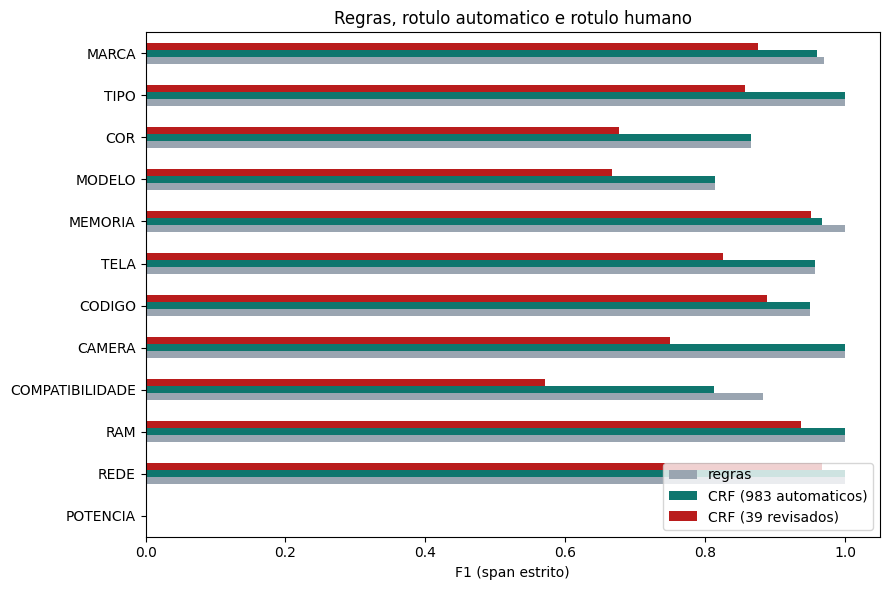

In [11]:
import matplotlib.pyplot as plt

por_tag = comparacao[~comparacao["tag"].isin(["micro", "macro"])].sort_values("suporte")
eixo = por_tag.plot.barh(x="tag", y=["regras", "crf_automatico", "crf_humano"],
                         figsize=(9, 6), color=["#9aa5b1", "#0f766e", "#b91c1c"])
eixo.set_xlabel("F1 (span estrito)")
eixo.set_ylabel("")
eixo.set_title("Regras, rotulo automatico e rotulo humano")
eixo.legend(["regras", "CRF (983 automaticos)", "CRF (39 revisados)"], loc="lower right")
plt.tight_layout()
plt.show()

In [12]:
resumo = pd.DataFrame([
    {"sistema": "regras", "titulos de treino": 0,
     "micro F1": micro_f1(teste, pred_regras)},
    {"sistema": "CRF com rotulo automatico", "titulos de treino": len(treino_auto),
     "micro F1": micro_f1(teste, pred_auto)},
    {"sistema": "CRF com rotulo humano", "titulos de treino": round(sum(tamanhos_treino) / PARTICOES),
     "micro F1": micro_f1(teste, pred_humano)},
])
resumo.round(3)

,sistema,titulos de treino,micro F1
0,regras,0,0.946
1,CRF com rotulo automatico,983,0.938
2,CRF com rotulo humano,39,0.818


## 6. Erros do modelo treinado com rotulo humano

In [13]:
pd.DataFrame(erros(teste, pred_humano, limite=15))

,titulo,trecho,esperado,obtido,tipo
0,Smartphone Motorola Moto Edge 30 Fusion 256GB ...,Moto Edge 30,MODELO,-,nao encontrado
1,Smartphone Motorola Moto Edge 30 Fusion 256GB ...,Fusion,MODELO,-,nao encontrado
2,Apple iPhone 14 Pro 512GB Preto-espacial,Preto-espacial,COR,-,nao encontrado
3,Celular Flip Vita Lite Multilaser Dual Chip Rá...,Flip,MODELO,-,nao encontrado
4,Celular Flip Vita Lite Multilaser Dual Chip Rá...,Vita,MODELO,-,nao encontrado
5,Celular Flip Vita Lite Multilaser Dual Chip Rá...,Lite,MODELO,-,nao encontrado
6,Combo Connect - Celular Multilaser Up Play Dua...,Celular,TIPO,-,nao encontrado
7,Combo Connect - Celular Multilaser Up Play Dua...,P9076K,MODELO,-,nao encontrado
8,"Capa com MagSafe para iPhone 13 Pro Apple, Sil...",Capa com MagSafe,TIPO,-,nao encontrado
9,"Capa com MagSafe para iPhone 13 Pro Apple, Sil...",Meia-Noite,COR,-,nao encontrado


## 7. Zero-shot (opcional)

Terceira via para escapar do teto: um modelo que ja sabe reconhecer entidades
sem ter visto este dataset. O GLiNER recebe os nomes das entidades em linguagem
natural e extrai os spans correspondentes.

Esta secao depende de baixar o modelo (cerca de 500 MB) e pode nao funcionar em
rede restrita. A celula trata a falha e segue: se nao rodar, registre a
limitacao do ambiente nas conclusoes, ja que os resultados das secoes anteriores
nao dependem dela.

In [ ]:
# pip install gliner

ROTULOS_NATURAIS = {
    "tipo de produto": "TIPO",
    "marca": "MARCA",
    "modelo do aparelho": "MODELO",
    "capacidade de armazenamento": "MEMORIA",
    "memoria ram": "RAM",
    "cor": "COR",
    "tamanho da tela": "TELA",
    "geracao de rede movel": "REDE",
    "resolucao da camera": "CAMERA",
    "capacidade da bateria": "BATERIA",
    "potencia eletrica": "POTENCIA",
    "codigo do fabricante": "CODIGO",
}

pred_zero = None
try:
    from gliner import GLiNER

    modelo_zero = GLiNER.from_pretrained("urchade/gliner_multi-v2.1")
    pred_zero = []
    for registro in teste:
        achados = modelo_zero.predict_entities(registro["text"], list(ROTULOS_NATURAIS), threshold=0.4)
        entidades = [[a["start"], a["end"], ROTULOS_NATURAIS[a["label"]]] for a in achados]
        pred_zero.append({"text": registro["text"], "entities": sorted(entidades)})
    print(f"micro F1: {micro_f1(teste, pred_zero):.3f}")
except Exception as erro:
    print("zero-shot nao executado neste ambiente:")
    print(f"  {type(erro).__name__}: {erro}")

In [ ]:
if pred_zero is not None:
    res_zero = pd.DataFrame(avaliar(teste, pred_zero))
    display(res_zero.round(3))
    display(pd.DataFrame(erros(teste, pred_zero, limite=10)))
else:
    print("secao sem resultado; ver observacao acima")

## 8. Conclusoes

**A hipotese inicial nao se confirmou.** O CRF treinado com cerca de 39 titulos
revisados manualmente obteve micro F1 de 0,818, abaixo dos 0,938 do mesmo modelo
treinado com 983 titulos rotulados automaticamente e dos 0,946 do baseline de
regras. Rotulo humano em pouca quantidade nao compensa rotulo automatico em
grande quantidade.

**Os dois experimentos juntos delimitam o problema.** O notebook 04 mostrou que
o modelo treinado em rotulo automatico nao ultrapassa quem o rotulou: empate
exato em oito das doze entidades e curva de aprendizado saturada (0,002 de ganho
entre 600 e 983 titulos). Este notebook mostra que trocar volume por qualidade,
na escala disponivel, piora o resultado. O gargalo nao e so qualidade nem so
volume: e a combinacao dos dois.

**A perda se concentra nas entidades de vocabulario aberto.** COR (-0,188) e
MODELO (-0,147) dependem de o modelo ter visto cada valor possivel, e 39 titulos
cobrem uma fracao pequena desse vocabulario. Ja MEMORIA (-0,016), REDE (-0,032)
e RAM (-0,062) quase nao sofrem, porque seu padrao esta na forma do token e nao
na lista de valores: sao aprendidas com poucos exemplos.

**CAMERA (-0,250) revela escassez absoluta.** O padrao e rigido (`13MP`) e
deveria ser facil, mas as 18 ocorrencias distribuidas em 5 particoes deixam cerca
de 14 exemplos por treino. Nao e dificuldade da entidade, e falta de dado.

**COMPATIBILIDADE e o caso dificil para todos os sistemas** (0,882 nas regras,
0,812 no CRF automatico, 0,571 no humano). Distinguir o modelo do produto do
modelo do aparelho compativel exige saber que o produto e um acessorio,
informacao que aparece no inicio do titulo e condiciona um span no meio. As
features locais de token nao alcancam essa dependencia.

**Recomendacao para o cenario de e-commerce.** A combinacao mais eficiente
observada e regra para as entidades de formato fixo (MEMORIA, RAM, REDE, CAMERA,
TIPO, com F1 entre 0,95 e 1,00) e aprendizado para as de vocabulario aberto,
desde que haja volume anotado suficiente. O caminho natural de continuacao seria
treinar no conjunto automatico e ajustar no revisado, aproveitando cobertura e
correcao ao mesmo tempo.

**Limitacoes.** O conjunto revisado tem 49 titulos, e diferencas por entidade se
apoiam em poucas ocorrencias; POTENCIA, com suporte 1, nao sustenta conclusao. A
avaliacao por validacao cruzada mede um regime de dados muito pequeno, e nao
permite extrapolar o desempenho do rotulo humano em escala maior. A abordagem
zero-shot nao pode ser avaliada por restricao de rede do ambiente, e fica
registrada como continuacao possivel.